## Loading Libraries

In [1]:
import cv2
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

## Extract Frames from SmartPhone Videos

In [2]:
def extract_frames(video_path, output_root="frames", frame_skip=1):
    """
    video_path: path to video file
    output_root: root folder to store frames
    frame_skip: save every nth frame
    """

    # Get video name (without extension)
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    # Create output directory for this video
    output_dir = os.path.join(output_root, video_name)
    os.makedirs(output_dir, exist_ok=True)

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return

    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Save every nth frame
        if frame_count % frame_skip == 0:
            filename = os.path.join(output_dir, f"frame_{saved_count:05d}.jpg")
            cv2.imwrite(filename, frame)
            saved_count += 1

        frame_count += 1

    cap.release()

    print(f"Saved {saved_count} frames to {output_dir}")

In [28]:
vid_path = './input_videos/main_building_1.mp4'
output_dir = './output_frames'
extract_frames(vid_path, output_dir, frame_skip = 50)

Saved 10 frames to ./output_frames/main_building_1


In [29]:
vid_path = './input_videos/main_building_2.mp4'
output_dir = './output_frames'
extract_frames(vid_path, output_dir, frame_skip = 40)

Saved 12 frames to ./output_frames/main_building_2


## Feature Extraction and Matching

In [7]:
def load_and_resize_images(folder_path, scale=0.5, max_dim=None):
    """
    scale: resize factor (e.g., 0.5)
    max_dim: alternatively limit max dimension
    """

    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    images = []

    for path in image_paths:
        img = cv2.imread(path)

        h, w = img.shape[:2]

        if max_dim is not None:
            scale_factor = max_dim / max(h, w)
        else:
            scale_factor = scale

        if scale_factor < 1.0:
            new_w = int(w * scale_factor)
            new_h = int(h * scale_factor)

            img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

        images.append(img)

    return images, image_paths

In [8]:
# Load images in sorted order
def load_images_from_folder(folder_path):
    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    images = [cv2.imread(p) for p in image_paths]
    return images, image_paths
    
# Initialize SIFT detector
def create_sift():
    sift = cv2.SIFT_create()
    return sift

In [10]:
# Extract features
def extract_features(images, sift):
    keypoints_list = []
    descriptors_list = []

    for idx, img in enumerate(images):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        keypoints, descriptors = sift.detectAndCompute(gray, None)

        keypoints_list.append(keypoints)
        descriptors_list.append(descriptors)

        print(f"[INFO] Image {idx}: {len(keypoints)} keypoints detected")

    return keypoints_list, descriptors_list

In [11]:
# -----------------------------
# Match features (with ratio test)
# -----------------------------
def match_features(desc1, desc2, ratio_thresh=0.75):
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

    matches = bf.knnMatch(desc1, desc2, k=2)

    good_matches = []

    for m, n in matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)

    return good_matches

# -----------------------------
# Match consecutive frames
# -----------------------------
def match_all_images(descriptors_list):
    all_matches = []

    for i in range(len(descriptors_list) - 1):
        desc1 = descriptors_list[i]
        desc2 = descriptors_list[i + 1]

        matches = match_features(desc1, desc2)

        print(f"[INFO] Matches between {i} and {i+1}: {len(matches)}")

        all_matches.append(matches)

    return all_matches


# -----------------------------
# Optional: visualize matches
# -----------------------------
def draw_matches(img1, kp1, img2, kp2, matches, max_matches=50):
    img_matches = cv2.drawMatches(
        img1, kp1,
        img2, kp2,
        matches[:max_matches],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    return img_matches

In [12]:
# -----------------------------
# Main pipeline
# -----------------------------
def run_feature_pipeline(folder_path):
    # images, paths = load_images_from_folder(folder_path)
    images, paths = load_and_resize_images(folder, scale=0.5)
    sift = create_sift()
    keypoints_list, descriptors_list = extract_features(images, sift)
    matches_list = match_all_images(descriptors_list)

    return images, keypoints_list, descriptors_list, matches_list

In [17]:
folder = "./output_frames/main_building_1"
images, keypoints, descriptors, matches = run_feature_pipeline(folder)

[INFO] Image 0: 384 keypoints detected
[INFO] Image 1: 321 keypoints detected
[INFO] Image 2: 240 keypoints detected
[INFO] Image 3: 342 keypoints detected
[INFO] Image 4: 1058 keypoints detected
[INFO] Image 5: 1009 keypoints detected
[INFO] Image 6: 1111 keypoints detected
[INFO] Image 7: 1124 keypoints detected
[INFO] Image 8: 975 keypoints detected
[INFO] Image 9: 942 keypoints detected
[INFO] Image 10: 893 keypoints detected
[INFO] Image 11: 804 keypoints detected
[INFO] Image 12: 740 keypoints detected
[INFO] Image 13: 742 keypoints detected
[INFO] Image 14: 595 keypoints detected
[INFO] Image 15: 560 keypoints detected
[INFO] Image 16: 536 keypoints detected
[INFO] Image 17: 722 keypoints detected
[INFO] Image 18: 1132 keypoints detected
[INFO] Image 19: 1391 keypoints detected
[INFO] Image 20: 1528 keypoints detected
[INFO] Image 21: 1504 keypoints detected
[INFO] Matches between 0 and 1: 124
[INFO] Matches between 1 and 2: 108
[INFO] Matches between 2 and 3: 117
[INFO] Matches

In [13]:
def get_matched_points(kp1, kp2, matches):
    pts1 = []
    pts2 = []

    for m in matches:
        pts1.append(kp1[m.queryIdx].pt)
        pts2.append(kp2[m.trainIdx].pt)

    pts1 = np.array(pts1)
    pts2 = np.array(pts2)

    return pts1, pts2

In [31]:
pts1, pts2 = get_matched_points(
    keypoints[1],
    keypoints[2],
    matches[1]
)

In [33]:
all_points = []

for i in range(len(matches)):
    pts1, pts2 = get_matched_points(
        keypoints[i],
        keypoints[i+1],
        matches[i]
    )

    print(f"[INFO] Pair {i}-{i+1}: {pts1.shape[0]} correspondences")

    all_points.append((pts1, pts2))

[INFO] Pair 0-1: 124 correspondences
[INFO] Pair 1-2: 108 correspondences
[INFO] Pair 2-3: 117 correspondences
[INFO] Pair 3-4: 71 correspondences
[INFO] Pair 4-5: 351 correspondences
[INFO] Pair 5-6: 399 correspondences
[INFO] Pair 6-7: 479 correspondences
[INFO] Pair 7-8: 448 correspondences
[INFO] Pair 8-9: 435 correspondences
[INFO] Pair 9-10: 418 correspondences
[INFO] Pair 10-11: 349 correspondences
[INFO] Pair 11-12: 290 correspondences
[INFO] Pair 12-13: 316 correspondences
[INFO] Pair 13-14: 247 correspondences
[INFO] Pair 14-15: 240 correspondences
[INFO] Pair 15-16: 228 correspondences
[INFO] Pair 16-17: 234 correspondences
[INFO] Pair 17-18: 318 correspondences
[INFO] Pair 18-19: 428 correspondences
[INFO] Pair 19-20: 625 correspondences
[INFO] Pair 20-21: 681 correspondences


## Normalization

In [14]:
import numpy as np

def normalize_points(pts):
    """
    pts: (N, 2)
    Returns:
        pts_normalized: (N, 2)
        T: (3, 3) normalization matrix
    """

    # Step 1: Compute centroid
    centroid = np.mean(pts, axis=0)
    
    # Step 2: Shift points
    pts_shifted = pts - centroid

    # Step 3: Compute mean distance
    dists = np.sqrt(np.sum(pts_shifted**2, axis=1))
    mean_dist = np.mean(dists)

    # Step 4: Compute scale
    scale = np.sqrt(2) / mean_dist

    # Step 5: Construct normalization matrix
    T = np.array([
        [scale, 0, -scale * centroid[0]],
        [0, scale, -scale * centroid[1]],
        [0, 0, 1]
    ])

    # Step 6: Convert to homogeneous
    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])

    # Step 7: Apply transformation
    pts_norm_h = (T @ pts_h.T).T

    # Convert back to Cartesian
    pts_normalized = pts_norm_h[:, :2] / pts_norm_h[:, 2][:, np.newaxis]

    return pts_normalized, T

## RANSAC

In [15]:
def compute_homography_dlt(pts1, pts2):
    """
    pts1, pts2: (N, 2) corresponding points
    Returns:
        H: (3, 3)
    """

    # Normalize points
    pts1_norm, T1 = normalize_points(pts1)
    pts2_norm, T2 = normalize_points(pts2)

    N = pts1.shape[0]
    A = []

    for i in range(N):
        x, y = pts1_norm[i]
        x_p, y_p = pts2_norm[i]

        A.append([-x, -y, -1, 0, 0, 0, x * x_p, y * x_p, x_p])
        A.append([0, 0, 0, -x, -y, -1, x * y_p, y * y_p, y_p])

    A = np.array(A)

    # Solve Ah = 0 using SVD
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1]  # last row

    H_norm = h.reshape(3, 3)

    # Denormalize
    H = np.linalg.inv(T2) @ H_norm @ T1

    # Normalize scale
    H = H / H[2, 2]

    return H

In [16]:
def compute_reprojection_error(H, pts1, pts2):
    """
    Returns reprojection errors for all points
    """

    pts1_h = np.hstack([pts1, np.ones((pts1.shape[0], 1))])
    projected = (H @ pts1_h.T).T

    projected = projected[:, :2] / projected[:, 2][:, np.newaxis]

    errors = np.linalg.norm(pts2 - projected, axis=1)

    return errors

In [17]:
def ransac_homography(pts1, pts2, num_iters=1000, threshold=3.0):
    """
    pts1, pts2: (N, 2)
    Returns:
        best_H, best_inliers
    """

    max_inliers = 0
    best_H = None
    best_inlier_mask = None

    N = pts1.shape[0]

    for _ in range(num_iters):

        # Step 1: Randomly sample 4 points
        indices = np.random.choice(N, 4, replace=False)
        sample_pts1 = pts1[indices]
        sample_pts2 = pts2[indices]

        # Step 2: Compute homography
        try:
            H = compute_homography_dlt(sample_pts1, sample_pts2)
        except:
            continue

        # Step 3: Compute error
        errors = compute_reprojection_error(H, pts1, pts2)

        # Step 4: Find inliers
        inlier_mask = errors < threshold
        num_inliers = np.sum(inlier_mask)

        # Step 5: Update best model
        if num_inliers > max_inliers:
            max_inliers = num_inliers
            best_H = H
            best_inlier_mask = inlier_mask

    # Step 6: Recompute using all inliers
    if best_inlier_mask is not None:
        best_H = compute_homography_dlt(
            pts1[best_inlier_mask],
            pts2[best_inlier_mask]
        )

    return best_H, best_inlier_mask

In [41]:
for i in range(len(matches)):
    pts1, pts2 = get_matched_points(
        keypoints[i],
        keypoints[i+1],
        matches[i]
    )

    if pts1.shape[0] < 4:
        continue

    H, inliers = ransac_homography(pts1, pts2)

    print(f"Pair {i}-{i+1}: {np.sum(inliers)} inliers")

/var/folders/1r/_914qhk557sg00dr01rhk18w0000gn/T/ipykernel_32144/499088685.py:9: RuntimeWarning: divide by zero encountered in divide
  projected = projected[:, :2] / projected[:, 2][:, np.newaxis]
/var/folders/1r/_914qhk557sg00dr01rhk18w0000gn/T/ipykernel_32144/499088685.py:9: RuntimeWarning: invalid value encountered in divide
  projected = projected[:, :2] / projected[:, 2][:, np.newaxis]


Pair 0-1: 101 inliers
Pair 1-2: 84 inliers
Pair 2-3: 92 inliers
Pair 3-4: 49 inliers
Pair 4-5: 275 inliers
Pair 5-6: 336 inliers
Pair 6-7: 412 inliers
Pair 7-8: 390 inliers
Pair 8-9: 395 inliers
Pair 9-10: 395 inliers
Pair 10-11: 319 inliers
Pair 11-12: 259 inliers
Pair 12-13: 290 inliers
Pair 13-14: 222 inliers
Pair 14-15: 204 inliers
Pair 15-16: 195 inliers
Pair 16-17: 214 inliers
Pair 17-18: 306 inliers
Pair 18-19: 412 inliers
Pair 19-20: 616 inliers
Pair 20-21: 660 inliers


## Stitching and Warping

In [18]:
def compute_global_homographies(pairwise_H, ref_idx):
    """
    pairwise_H[i]: H from i -> i+1
    ref_idx: index of reference image

    Returns:
        global_H[i]: H from i -> reference
    """

    n = len(pairwise_H) + 1
    global_H = [None] * n

    # Reference image
    global_H[ref_idx] = np.eye(3)

    # Forward direction (ref -> end)
    for i in range(ref_idx, n - 1):
        global_H[i + 1] = global_H[i] @ np.linalg.inv(pairwise_H[i])

    # Backward direction (ref -> start)
    for i in range(ref_idx - 1, -1, -1):
        global_H[i] = global_H[i + 1] @ pairwise_H[i]

    return global_H

In [19]:
def get_canvas_bounds(images, homographies):
    """
    Compute bounding box for all warped images
    """

    all_corners = []

    for img, H in zip(images, homographies):
        h, w = img.shape[:2]

        corners = np.array([
            [0, 0],
            [w, 0],
            [w, h],
            [0, h]
        ])

        corners_h = np.hstack([corners, np.ones((4, 1))])
        warped = (H @ corners_h.T).T
        warped = warped[:, :2] / warped[:, 2][:, np.newaxis]

        all_corners.append(warped)

    all_corners = np.vstack(all_corners)

    x_min, y_min = np.min(all_corners, axis=0)
    x_max, y_max = np.max(all_corners, axis=0)

    return x_min, y_min, x_max, y_max

In [20]:
import numpy as np
import cv2

def warp_and_stitch(images, homographies):
    """
    Corrected warping + blending
    """

    x_min, y_min, x_max, y_max = get_canvas_bounds(images, homographies)

    # Translation matrix
    translation = np.array([
        [1, 0, -x_min],
        [0, 1, -y_min],
        [0, 0, 1]
    ])

    width = int(np.ceil(x_max - x_min))
    height = int(np.ceil(y_max - y_min))

    # IMPORTANT: float canvas
    canvas = np.zeros((height, width, 3), dtype=np.float32)
    weight = np.zeros((height, width), dtype=np.float32)

    for img, H in zip(images, homographies):

        H_total = translation @ H

        warped = cv2.warpPerspective(
            img,
            H_total,
            (width, height),
            flags=cv2.INTER_LINEAR
        )

        # Create mask properly (non-black pixels)
        mask = (np.sum(warped, axis=2) > 0).astype(np.float32)

        # Expand mask for channels
        mask_3c = np.stack([mask]*3, axis=2)

        # Accumulate weighted sum
        canvas += warped.astype(np.float32) * mask_3c
        weight += mask

    # Normalize safely
    weight[weight == 0] = 1
    canvas /= weight[:, :, np.newaxis]

    return canvas.astype(np.uint8)

In [60]:
folder = "./output_frames/main_building_2"
images, keypoints, descriptors, matches = run_feature_pipeline(folder)

[INFO] Image 0: 485 keypoints detected
[INFO] Image 1: 435 keypoints detected
[INFO] Image 2: 442 keypoints detected
[INFO] Image 3: 379 keypoints detected
[INFO] Image 4: 353 keypoints detected
[INFO] Image 5: 318 keypoints detected
[INFO] Image 6: 247 keypoints detected
[INFO] Image 7: 198 keypoints detected
[INFO] Image 8: 203 keypoints detected
[INFO] Image 9: 265 keypoints detected
[INFO] Image 10: 298 keypoints detected
[INFO] Image 11: 269 keypoints detected
[INFO] Image 12: 285 keypoints detected
[INFO] Image 13: 362 keypoints detected
[INFO] Image 14: 326 keypoints detected
[INFO] Image 15: 316 keypoints detected
[INFO] Image 16: 475 keypoints detected
[INFO] Image 17: 719 keypoints detected
[INFO] Image 18: 982 keypoints detected
[INFO] Image 19: 994 keypoints detected
[INFO] Matches between 0 and 1: 259
[INFO] Matches between 1 and 2: 227
[INFO] Matches between 2 and 3: 219
[INFO] Matches between 3 and 4: 190
[INFO] Matches between 4 and 5: 166
[INFO] Matches between 5 and 6

In [61]:
all_points = []

for i in range(len(matches)):
    pts1, pts2 = get_matched_points(
        keypoints[i],
        keypoints[i+1],
        matches[i]
    )

    print(f"[INFO] Pair {i}-{i+1}: {pts1.shape[0]} correspondences")

    all_points.append((pts1, pts2))

[INFO] Pair 0-1: 259 correspondences
[INFO] Pair 1-2: 227 correspondences
[INFO] Pair 2-3: 219 correspondences
[INFO] Pair 3-4: 190 correspondences
[INFO] Pair 4-5: 166 correspondences
[INFO] Pair 5-6: 133 correspondences
[INFO] Pair 6-7: 86 correspondences
[INFO] Pair 7-8: 85 correspondences
[INFO] Pair 8-9: 104 correspondences
[INFO] Pair 9-10: 117 correspondences
[INFO] Pair 10-11: 128 correspondences
[INFO] Pair 11-12: 126 correspondences
[INFO] Pair 12-13: 162 correspondences
[INFO] Pair 13-14: 164 correspondences
[INFO] Pair 14-15: 98 correspondences
[INFO] Pair 15-16: 87 correspondences
[INFO] Pair 16-17: 200 correspondences
[INFO] Pair 17-18: 274 correspondences
[INFO] Pair 18-19: 335 correspondences


In [62]:
pairwise_H = []

for i in range(len(matches)):
    pts1, pts2 = get_matched_points(
        keypoints[i],
        keypoints[i+1],
        matches[i]
    )

    if pts1.shape[0] < 4:
        pairwise_H.append(np.eye(3))
        continue

    H, inliers = ransac_homography(pts1, pts2)

    pairwise_H.append(H)

/var/folders/1r/_914qhk557sg00dr01rhk18w0000gn/T/ipykernel_32144/499088685.py:9: RuntimeWarning: divide by zero encountered in divide
  projected = projected[:, :2] / projected[:, 2][:, np.newaxis]
/var/folders/1r/_914qhk557sg00dr01rhk18w0000gn/T/ipykernel_32144/499088685.py:9: RuntimeWarning: invalid value encountered in divide
  projected = projected[:, :2] / projected[:, 2][:, np.newaxis]


In [63]:
ref_idx = len(images) // 2
global_H = compute_global_homographies(pairwise_H, ref_idx)
panorama = warp_and_stitch(images, global_H)

In [23]:
import cv2
import numpy as np
import os
from glob import glob


# -----------------------------
# 1. Load + Resize Images
# -----------------------------
def load_and_resize_images(folder_path, max_dim=800):
    image_paths = sorted(glob(os.path.join(folder_path, "*.jpg")))
    images = []

    for path in image_paths:
        img = cv2.imread(path)
        h, w = img.shape[:2]

        scale = max_dim / max(h, w)
        if scale < 1.0:
            img = cv2.resize(img, (int(w * scale), int(h * scale)))

        images.append(img)

    print(f"[INFO] Loaded {len(images)} images")
    return images


# -----------------------------
# 2. Feature Extraction (SIFT)
# -----------------------------
def extract_features(images):
    sift = cv2.SIFT_create()

    keypoints, descriptors = [], []

    for i, img in enumerate(images):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        kp, desc = sift.detectAndCompute(gray, None)

        keypoints.append(kp)
        descriptors.append(desc)

        print(f"[INFO] Image {i}: {len(kp)} keypoints")

    return keypoints, descriptors


# -----------------------------
# 3. Feature Matching
# -----------------------------
def match_features(desc1, desc2, ratio=0.75):
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(desc1, desc2, k=2)

    good = []
    for m, n in matches:
        if m.distance < ratio * n.distance:
            good.append(m)

    return good


def get_all_matches(descriptors):
    matches_all = []

    for i in range(len(descriptors) - 1):
        matches = match_features(descriptors[i], descriptors[i+1])
        print(f"[INFO] Pair {i}-{i+1}: {len(matches)} correspondences")
        matches_all.append(matches)

    return matches_all


# -----------------------------
# 4. Get Matched Points
# -----------------------------
def get_matched_points(kp1, kp2, matches):
    pts1, pts2 = [], []

    for m in matches:
        pts1.append(kp1[m.queryIdx].pt)
        pts2.append(kp2[m.trainIdx].pt)

    return np.array(pts1), np.array(pts2)


# -----------------------------
# 5. Normalize Points
# -----------------------------
def normalize_points(pts):
    centroid = np.mean(pts, axis=0)
    pts_shifted = pts - centroid

    mean_dist = np.mean(np.sqrt(np.sum(pts_shifted**2, axis=1)))
    scale = np.sqrt(2) / mean_dist

    T = np.array([
        [scale, 0, -scale * centroid[0]],
        [0, scale, -scale * centroid[1]],
        [0, 0, 1]
    ])

    pts_h = np.hstack([pts, np.ones((pts.shape[0], 1))])
    pts_norm = (T @ pts_h.T).T

    return pts_norm[:, :2], T


# -----------------------------
# 6. Homography (DLT)
# -----------------------------
def compute_homography_dlt(pts1, pts2):
    pts1, T1 = normalize_points(pts1)
    pts2, T2 = normalize_points(pts2)

    A = []

    for (x, y), (xp, yp) in zip(pts1, pts2):
        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])

    A = np.array(A)

    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)

    H = np.linalg.inv(T2) @ H @ T1
    return H / H[2, 2]


# -----------------------------
# 7. RANSAC
# -----------------------------
def ransac_homography(pts1, pts2, iters=1000, thresh=3):
    best_H = None
    max_inliers = 0
    best_mask = None

    N = pts1.shape[0]

    for _ in range(iters):
        idx = np.random.choice(N, 4, replace=False)

        try:
            H = compute_homography_dlt(pts1[idx], pts2[idx])
        except:
            continue

        pts1_h = np.hstack([pts1, np.ones((N, 1))])
        proj = (H @ pts1_h.T).T
        proj = proj[:, :2] / proj[:, 2][:, None]

        error = np.linalg.norm(pts2 - proj, axis=1)
        mask = error < thresh

        if np.sum(mask) > max_inliers:
            best_H = H
            max_inliers = np.sum(mask)
            best_mask = mask

    return best_H, best_mask


# -----------------------------
# 8. Compute Global Homographies
# -----------------------------
def compute_global_homographies(pairwise_H, ref_idx):
    n = len(pairwise_H) + 1
    H_global = [None] * n

    H_global[ref_idx] = np.eye(3)

    for i in range(ref_idx, n-1):
        H_global[i+1] = H_global[i] @ np.linalg.inv(pairwise_H[i])

    for i in range(ref_idx-1, -1, -1):
        H_global[i] = H_global[i+1] @ pairwise_H[i]

    return H_global


# -----------------------------
# 9. Canvas Bounds
# -----------------------------
def get_canvas_bounds(images, Hs):
    corners_all = []

    for img, H in zip(images, Hs):
        h, w = img.shape[:2]
        corners = np.array([[0,0],[w,0],[w,h],[0,h]])

        corners_h = np.hstack([corners, np.ones((4,1))])
        warped = (H @ corners_h.T).T
        warped = warped[:, :2] / warped[:, 2][:, None]

        corners_all.append(warped)

    corners_all = np.vstack(corners_all)

    return np.min(corners_all, axis=0), np.max(corners_all, axis=0)


# -----------------------------
# 10. Warp + Stitch
# -----------------------------
def warp_and_stitch(images, Hs):
    (xmin, ymin), (xmax, ymax) = get_canvas_bounds(images, Hs)

    T = np.array([
        [1, 0, -xmin],
        [0, 1, -ymin],
        [0, 0, 1]
    ])

    width = int(xmax - xmin)
    height = int(ymax - ymin)

    canvas = np.zeros((height, width, 3), dtype=np.float32)
    weight = np.zeros((height, width), dtype=np.float32)

    for i, (img, H) in enumerate(zip(images, Hs)):
        print(f"[INFO] Warping image {i}")

        warped = cv2.warpPerspective(img, T @ H, (width, height))

        mask = (np.sum(warped, axis=2) > 0).astype(np.float32)
        mask3 = np.stack([mask]*3, axis=2)

        canvas += warped.astype(np.float32) * mask3
        weight += mask

    weight[weight == 0] = 1
    canvas /= weight[:, :, None]

    return canvas.astype(np.uint8)


# -----------------------------
# 11. DRIVER FUNCTION
# -----------------------------
def run_panorama(folder_path):

    # Load images
    images = load_and_resize_images(folder_path)

    # Features
    keypoints, descriptors = extract_features(images)

    # Matching
    matches = get_all_matches(descriptors)

    # Homographies
    pairwise_H = []

    for i in range(len(matches)):
        pts1, pts2 = get_matched_points(
            keypoints[i],
            keypoints[i+1],
            matches[i]
        )

        if len(pts1) < 4:
            pairwise_H.append(np.eye(3))
            continue

        H, mask = ransac_homography(pts1, pts2)
        pairwise_H.append(H)

    # Reference frame
    ref_idx = len(images) // 2

    # Global homographies
    H_global = compute_global_homographies(pairwise_H, ref_idx)

    # Stitch
    panorama = warp_and_stitch(images, H_global)

    return panorama

In [32]:
folder = "./output_frames/main_building_2"
panorama = run_panorama(folder)

[INFO] Loaded 12 images
[INFO] Image 0: 1463 keypoints
[INFO] Image 1: 1419 keypoints
[INFO] Image 2: 1320 keypoints
[INFO] Image 3: 1068 keypoints
[INFO] Image 4: 787 keypoints
[INFO] Image 5: 993 keypoints
[INFO] Image 6: 1180 keypoints
[INFO] Image 7: 1279 keypoints
[INFO] Image 8: 1599 keypoints
[INFO] Image 9: 2036 keypoints
[INFO] Image 10: 3831 keypoints
[INFO] Image 11: 4652 keypoints
[INFO] Pair 0-1: 522 correspondences
[INFO] Pair 1-2: 567 correspondences
[INFO] Pair 2-3: 472 correspondences
[INFO] Pair 3-4: 303 correspondences
[INFO] Pair 4-5: 288 correspondences
[INFO] Pair 5-6: 253 correspondences
[INFO] Pair 6-7: 379 correspondences
[INFO] Pair 7-8: 528 correspondences
[INFO] Pair 8-9: 291 correspondences
[INFO] Pair 9-10: 546 correspondences
[INFO] Pair 10-11: 938 correspondences


/var/folders/1r/_914qhk557sg00dr01rhk18w0000gn/T/ipykernel_36914/454001615.py:151: RuntimeWarning: divide by zero encountered in divide
  proj = proj[:, :2] / proj[:, 2][:, None]
/var/folders/1r/_914qhk557sg00dr01rhk18w0000gn/T/ipykernel_36914/454001615.py:151: RuntimeWarning: invalid value encountered in divide
  proj = proj[:, :2] / proj[:, 2][:, None]


[INFO] Warping image 0
[INFO] Warping image 1
[INFO] Warping image 2
[INFO] Warping image 3
[INFO] Warping image 4
[INFO] Warping image 5
[INFO] Warping image 6
[INFO] Warping image 7
[INFO] Warping image 8
[INFO] Warping image 9
[INFO] Warping image 10
[INFO] Warping image 11


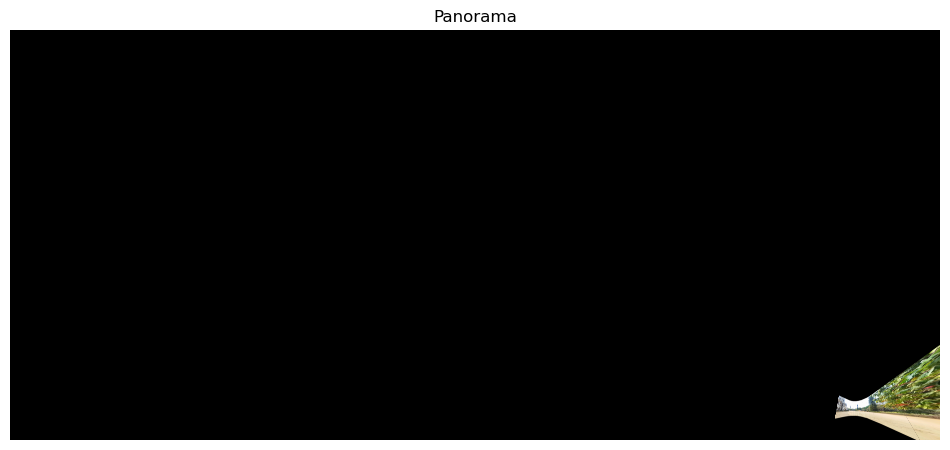

True

In [33]:

# Display
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Panorama")
plt.show()

cv2.imwrite("panorama_2.jpg", panorama)